# Tutorial: Spatially Resolved GWAS Mapping with gsMap

This tutorial demonstrates how to use [gsMap](https://github.com/JianYang-Lab/gsMap) to map GWAS-associated cells at single-cell spatial resolution. Two cellink helpers are used to make the execution even smoother:

- `format_gsmap_sumstats` — converts a GWAS DataFrame into the SNP/A1/A2/Z/N format gsMap expects, handling column remapping and mixed-type coercion automatically
- `load_gsmap_results` — reads the output CSV files back into DataFrames for downstream analysis in Python

**gsMap** works by assigning a gene specificity score (GSS) to each spatial spot, linking GSS to nearby SNPs, and using stratified LD score regression (S-LDSC) to test whether spots with high gene specificity are enriched for GWAS heritability. The Cauchy combination test then aggregates spot-level p-values into region-level associations.

## Environment Setup

Install gsMap and the cellink package:

```bash
pip install gsmap
pip install git+https://github.com/theislab/cellink.git@main
```

Download the gsMap resource bundle. This contains pre-built SNP-gene weight matrices and baseline LD score annotations required for quick mode (~several GB):

```bash
wget https://yanglab.westlake.edu.cn/data/gsMap/gsMap_resource.tar.gz
tar -xvzf gsMap_resource.tar.gz
```

Download the example 10X Visium data used in this tutorial:

```bash
wget https://yanglab.westlake.edu.cn/data/gsMap/Visium_example_data.tar.gz
tar -xvzf Visium_example_data.tar.gz
```


In [14]:
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

from cellink.resources import get_gwas_catalog_study_summary_stats
from cellink.tl.external import format_gsmap_sumstats, load_gsmap_results

# Paths — adjust to your environment
GSMAP_RESOURCE_DIR = Path("./gsMap_resource")
WORKDIR            = Path("./gsmap_output")
SAMPLE_NAME        = "V1_Adult_Mouse_Brain_Coronal"
HOMOLOG_FILE       = GSMAP_RESOURCE_DIR / "homologs/mouse_human_homologs.txt"
TRAIT_NAME         = "IQ"

WORKDIR.mkdir(parents=True, exist_ok=True)


## 1. Load and Prepare Spatial Transcriptomics Data

gsMap reads directly from an h5ad file. We load it here to inspect the structure and subsample for tutorial speed, then write it back to disk for the `gsmap` CLI to consume.


In [15]:
adata = sc.read_h5ad(
    "./Visium_example_data/ST/V1_Adult_Mouse_Brain_Coronal_Section.h5ad"
)
print(f"Full dataset: {adata.n_obs} spots × {adata.n_vars} genes")
print(f"Layers:       {list(adata.layers.keys())}")
print(f"Annotations:  {adata.obs.columns.tolist()}")


Full dataset: 2902 spots × 32285 genes
Layers:       ['count']
Annotations:  ['in_tissue', 'array_row', 'array_col', 'domain']


/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_pgen/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Subsampling for tutorial speed

The full section has ~2,900 spots. gsMap runtime scales with spot count, so we subsample to **300 spots** to keep the run under ~1 minute. Remove this cell for a real analysis.


In [16]:
sc.pp.subsample(adata, n_obs=300, random_state=42)
adata.obs['domain'] = adata.obs['domain'].astype(str)
print(f"Subsampled: {adata.n_obs} spots")
print(adata.obs['domain'].value_counts())


Subsampled: 300 spots
domain
3    78
1    63
4    44
2    39
5    39
6    37
Name: count, dtype: int64


/tmp/ipykernel_2103704/1886953810.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
... storing 'domain' as categorical


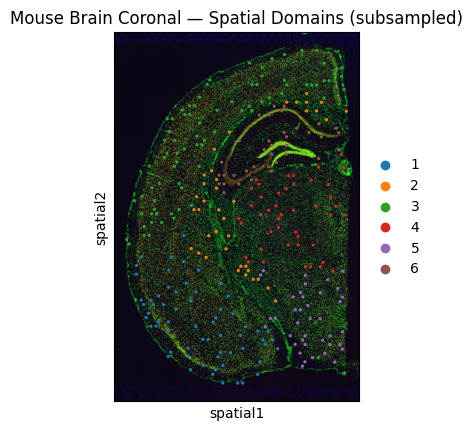

In [17]:
sc.pl.spatial(
    adata,
    color="domain",
    title="Mouse Brain Coronal — Spatial Domains (subsampled)",
)


We write the (subsampled) AnnData to an h5ad file that the `gsmap` CLI will read. In a production run you would point directly at your existing h5ad.


In [18]:
HDF5_PATH = WORKDIR / f"{SAMPLE_NAME}.h5ad"
adata.write_h5ad(HDF5_PATH)
print(f"Written to {HDF5_PATH}")


Written to gsmap_output/V1_Adult_Mouse_Brain_Coronal.h5ad


## 2. Prepare GWAS Summary Statistics

gsMap requires GWAS summary statistics with columns SNP, A1, A2, Z, N (gzip-compressed). We download IQ GWAS summary statistics from the GWAS Catalog (Savage et al. 2018, Nature Genetics — the same study used in the gsMap paper).


In [6]:
gwas_df = get_gwas_catalog_study_summary_stats("GCST006250")
print(gwas_df.columns.tolist())
gwas_df.head()


[2026-04-02 02:07:52,996] INFO:root: Fetching https://www.ebi.ac.uk/gwas/rest/api/v2/studies/GCST006250
[2026-04-02 02:07:53,342] INFO:root: Selected file with build unknown (priority selection): 29942086-GCST006250-EFO_0004337.h.tsv.gz
[2026-04-02 02:07:53,343] INFO:root: Using harmonised summary statistics (build: unknown)
[2026-04-02 02:07:53,345] INFO:root: Downloading http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST006001-GCST007000/GCST006250/harmonised/29942086-GCST006250-EFO_0004337.h.tsv.gz to /home/icb/lucas.arnoldt/cellink_data/GCST006250_summary_stats.tsv.gz


Two things to be aware of with GWAS Catalog harmonised files:

1. **Duplicate beta columns**: this file has both `hm_beta` and a plain `beta` column containing identical values. `gsmap format_sumstats` auto-detects both as beta columns and raises `ValueError: Found 2 different BETA columns`. `format_gsmap_sumstats` avoids this by writing only the columns you explicitly name to the temporary file — so gsMap never sees the extra `beta` column.

2. **INFO score filtering**: the file has a `mininfo` column with values around 0.6–0.8. `gsmap format_sumstats` defaults to `info_min=0.9`, which silently filters out every single SNP, leaving 0 SNPs in the output and causing the downstream jackknife regression to fail with `ValueError: More dimensions than datapoints`. Set `info_min=0.0` to skip INFO filtering for this file.


In [7]:
SUMSTATS_FILE = format_gsmap_sumstats(
    sumstats=gwas_df,
    out_prefix=str(WORKDIR / TRAIT_NAME),
    snp="hm_rsid",        # harmonised rs-IDs matching the HapMap3 panel
    a1="hm_effect_allele",
    a2="hm_other_allele",
    beta="hm_beta",
    p="p_value",
    n="n_analyzed",       # per-SNP sample size column in this file
    info_min=0.0,          # skip INFO filtering; mininfo values here are ~0.6-0.8
)
print(f"Formatted sumstats: {SUMSTATS_FILE}")


[2026-04-02 01:43:17,282] INFO:cellink.tl.external._gsmap: Wrote temporary sumstats to /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/_gsmap_sumstats_IQ_tmp.txt
[2026-04-02 01:43:17,283] INFO:cellink.tl.external._gsmap: Running: gsmap format_sumstats --sumstats /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/_gsmap_sumstats_IQ_tmp.txt --out gsmap_output/IQ --info_min 0.0 --maf_min 0.01 --snp hm_rsid --a1 hm_effect_allele --a2 hm_other_allele --beta hm_beta --p p_value --n n_analyzed
[2026-04-02 01:45:29,871] INFO:cellink.tl.external._gsmap:                                    ___  ___            
                                   |  \/  |            
                          __ _ ___ | .  . | __ _ _ __  
                         / _` / __|| |\/| |/ _` | '_ \ 
                        | (_| \__ \| |  | | (_| | |_) |
                         \__, |___/\_|  |_/\__,_| .__/ 
                          __/ |                 | |    


## 3. Run gsMap (Quick Mode)

Quick mode runs the entire pipeline — GNN latent representations, gene specificity scores, LD score computation, spatial LDSC, and Cauchy combination — in a single command, using pre-built SNP-gene weight matrices from the resource bundle. This is the recommended starting point.

The mouse Visium data uses mouse gene names, so we pass `--homolog_file` to convert them to human gene names before linking to the human GWAS.

**Memory**: quick mode requires ~80 GB for 120K-cell Stereo-seq data; ~10 GB for Visium (~3K spots).


In [8]:
cmd = [
    "gsmap", "quick_mode",
    "--workdir",            str(WORKDIR),
    "--sample_name",        SAMPLE_NAME,
    "--gsMap_resource_dir", str(GSMAP_RESOURCE_DIR),
    "--hdf5_path",          str(HDF5_PATH),
    "--annotation",         "domain",
    "--data_layer",         "count",
    "--sumstats_file",      str(SUMSTATS_FILE),
    "--trait_name",         TRAIT_NAME,
    "--homolog_file",       str(HOMOLOG_FILE),
    # Reduce neighbour counts to match the smaller subsampled dataset
    "--num_neighbour",         "11",
    "--num_neighbour_spatial",  "21",
    "--max_processes",       "4",
]

print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-3000:])  # tail of stdout
if result.returncode != 0:
    raise RuntimeError(f"gsmap failed:\n{result.stderr}")


Running: gsmap quick_mode --workdir gsmap_output --sample_name V1_Adult_Mouse_Brain_Coronal --gsMap_resource_dir gsMap_resource --hdf5_path gsmap_output/V1_Adult_Mouse_Brain_Coronal.h5ad --annotation domain --data_layer count --sumstats_file gsmap_output/IQ.sumstats.gz --trait_name IQ --homolog_file gsMap_resource/homologs/mouse_human_homologs.txt --num_neighbour 11 --num_neighbour_spatial 21 --max_processes 4
                                   ___  ___            
                                   |  \/  |            
                          __ _ ___ | .  . | __ _ _ __  
                         / _` / __|| |\/| |/ _` | '_ \ 
                        | (_| \__ \| |  | | (_| | |_) |
                         \__, |___/\_|  |_/\__,_| .__/ 
                          __/ |                 | |    
                         |___/                  |_|
                                Version: 1.73.7                                 
Using the following arguments for RunAllModeConfig:
{   'anno

Quick mode already runs the Cauchy combination test when `--annotation` is provided. If you need to re-run it separately (e.g. after updating annotations), use:

```bash
gsmap run_cauchy_combination \
    --workdir ./gsmap_output \
    --sample_name V1_Adult_Mouse_Brain_Coronal \
    --trait_name IQ \
    --annotation domain
```


## 4. Load and Explore Results

gsMap writes two key output files:
- **`spatial_ldsc/`** — per-spot association results (beta, se, z, p)
- **`cauchy_combination/`** — region-level aggregated p-values

We use `load_gsmap_results` to read both into DataFrames.


In [9]:
results = load_gsmap_results(
    workdir=WORKDIR,
    sample_name=SAMPLE_NAME,
    trait_name=TRAIT_NAME,
    annotation="domain",
)

spot_df   = results["spatial_ldsc"]
cauchy_df = results["cauchy_combination"]

print(f"Spot-level results:  {spot_df.shape}")
spot_df.head()


[2026-04-02 01:50:59,350] INFO:cellink.tl.external._gsmap: Loaded spatial LDSC results from gsmap_output/V1_Adult_Mouse_Brain_Coronal/spatial_ldsc/V1_Adult_Mouse_Brain_Coronal_IQ.csv.gz
[2026-04-02 01:50:59,407] INFO:cellink.tl.external._gsmap: Loaded Cauchy combination results from gsmap_output/V1_Adult_Mouse_Brain_Coronal/cauchy_combination/V1_Adult_Mouse_Brain_Coronal_IQ.Cauchy.csv.gz
[2026-04-02 01:50:59,407] INFO:cellink.tl.external._gsmap: Report available at: gsmap_output/V1_Adult_Mouse_Brain_Coronal/report
Spot-level results:  (300, 5)


,spot,beta,se,z,p
0,AATCCAAGGGCCTGAG-1,7.429476e-09,1.249947e-09,5.943835,1.392147e-09
1,CACTTAATCAGACGGA-1,3.391277e-09,1.125493e-09,3.013147,1.292768e-03
2,AGTATGCTGGAGACCA-1,2.354180e-09,1.572288e-09,1.497296,6.715817e-02
3,GCGAGGCCCGAGCAGA-1,4.520556e-09,1.137244e-09,3.975009,3.518825e-05
4,CGGGCAGCTAAACCGC-1,1.545595e-09,1.170099e-09,1.320909,9.326582e-02


In [10]:
print("Region-level results (Cauchy combination):")
print(cauchy_df.sort_values("p_cauchy"))


Region-level results (Cauchy combination):
                p_cauchy      p_median
annotation                            
3           1.472224e-16  3.575110e-11
6           5.218048e-15  9.454144e-09
1           1.434441e-10  1.148344e-05
4           3.859796e-09  2.191016e-05
5           6.840585e-07  3.472890e-06
2           1.450760e-02  2.553214e-01


## 5. Visualise Results

### Spatial map of IQ associations
We add the per-spot −log₁₀(p) to `adata.obs` and overlay it on the tissue section.


/tmp/ipykernel_2103704/3452492459.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='domain',
/tmp/ipykernel_2103704/3452492459.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='IQ_gsmap_neglog10p',


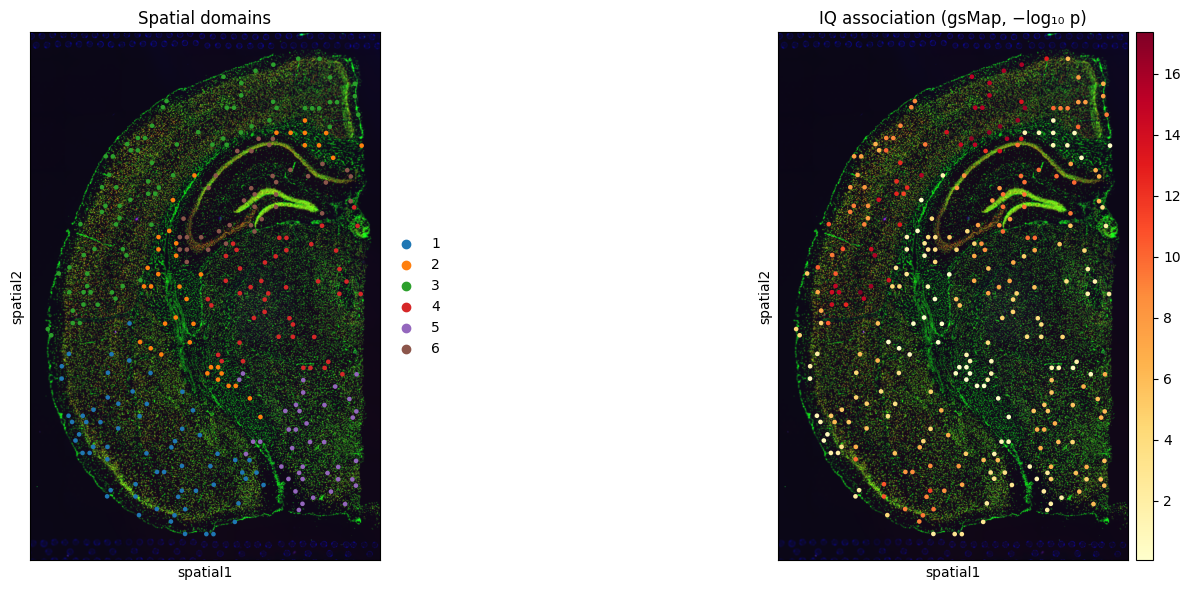

In [11]:
if spot_df is not None and len(spot_df) == adata.n_obs and 'p' in spot_df.columns:
    adata.obs['IQ_gsmap_neglog10p'] = -np.log10(spot_df['p'].values.clip(min=1e-300))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.spatial(adata, color='domain',
              title='Spatial domains', ax=axes[0], show=False)
sc.pl.spatial(adata, color='IQ_gsmap_neglog10p',
              title='IQ association (gsMap, −log₁₀ p)',
              cmap='YlOrRd', ax=axes[1], show=False)
plt.tight_layout()
plt.savefig(WORKDIR / 'gsmap_IQ_spatial.png', dpi=200)
plt.show()


### Region-level bar chart


[2026-04-02 01:51:01,866] INFO:matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-04-02 01:51:01,868] INFO:matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


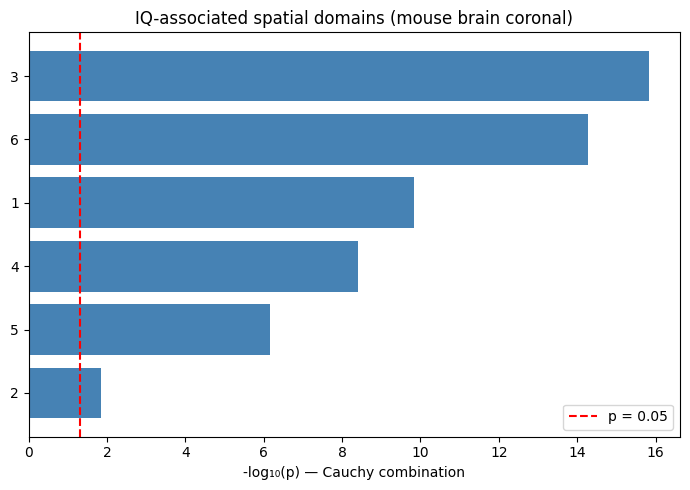

In [12]:
if cauchy_df is not None and 'p_cauchy' in cauchy_df.columns:
    plot_df = cauchy_df.copy()
    plot_df['-log10p'] = -np.log10(plot_df['p_cauchy'].clip(lower=1e-30))
    plot_df = plot_df.sort_values('-log10p', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(plot_df.index.astype(str), plot_df['-log10p'], color='steelblue')
    ax.axvline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
    ax.set_xlabel('-log₁₀(p) — Cauchy combination')
    ax.set_title('IQ-associated spatial domains (mouse brain coronal)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(WORKDIR / 'gsmap_IQ_cauchy.png', dpi=200)
    plt.show()


## 6. Generate the gsMap HTML Report

gsMap can generate an interactive HTML report with spatial visualisations and diagnostic plots. This step requires the full (non-subsampled) dataset for meaningful results and takes a few minutes.


In [13]:
cmd_report = [
    "gsmap", "run_report",
    "--workdir",      str(WORKDIR),
    "--sample_name",  SAMPLE_NAME,
    "--trait_name",   TRAIT_NAME,
    "--annotation",   "domain",
    "--sumstats_file", str(SUMSTATS_FILE),
    "--top_corr_genes", "50",
]

result = subprocess.run(cmd_report, capture_output=True, text=True)
if result.returncode != 0:
    print(f"Report generation failed (non-fatal): {result.stderr[-500:]}")
else:
    report_dir = WORKDIR / SAMPLE_NAME / 'report'
    print(f"Report written to {report_dir}")
    print("Copy the folder to your local machine and open index.html in a browser.")


Report written to gsmap_output/V1_Adult_Mouse_Brain_Coronal/report
Copy the folder to your local machine and open index.html in a browser.


## 7. Advanced Usage

### Multiple traits in one run

gsMap reuses latent representations and LD scores across traits in the same `--workdir`, so analysing multiple traits is efficient. Provide a YAML config file instead of `--sumstats_file`:

```yaml
# gwas_config.yaml
IQ: Visium_example_data/GWAS/IQ_NG_2018.sumstats.gz
Serum_creatinine: Visium_example_data/GWAS/Serum_creatinine.sumstats.gz
```

```bash
gsmap quick_mode \
    --workdir ./gsmap_output \
    --sample_name V1_Adult_Mouse_Brain_Coronal \
    --gsMap_resource_dir ./gsMap_resource \
    --hdf5_path ./gsmap_output/V1_Adult_Mouse_Brain_Coronal.h5ad \
    --annotation domain \
    --data_layer count \
    --sumstats_config_file gwas_config.yaml \
    --homolog_file ./gsMap_resource/homologs/mouse_human_homologs.txt
```


### Step-by-step mode with custom LD reference

Step-by-step mode gives full control over each pipeline stage and is useful when you want to use a custom GTF, run conditional analyses, or tune GNN parameters. It runs `generate_ldscore` for all 22 chromosomes and is compute-intensive — submit to a cluster in practice.

The steps are:

```bash
# Step 1: Learn GNN latent representations
gsmap run_find_latent_representations \
    --workdir ./gsmap_output --sample_name my_sample \
    --input_hdf5_path my_sample.h5ad --data_layer count --annotation cell_type

# Step 2: Compute gene specificity scores
gsmap run_latent_to_gene \
    --workdir ./gsmap_output --sample_name my_sample \
    --annotation cell_type --num_neighbour 51 --num_neighbour_spatial 201 \
    --homolog_file ./gsMap_resource/homologs/mouse_human_homologs.txt

# Step 3: Compute LD scores (run for each chromosome)
for CHROM in $(seq 1 22); do
    gsmap run_generate_ldscore \
        --workdir ./gsmap_output --sample_name my_sample --chrom $CHROM \
        --bfile_root ./gsMap_resource/LD_Reference_Panel/1000G_EUR_Phase3_plink/1000G.EUR.QC \
        --gtf_annotation_file ./gsMap_resource/genome_annotation/gtf/gencode.v46lift37.basic.annotation.gtf \
        --keep_snp_root ./gsMap_resource/LDSC_resource/hapmap3_snps/hm
done

# Step 4: Run spatial LDSC
gsmap run_spatial_ldsc \
    --workdir ./gsmap_output --sample_name my_sample \
    --sumstats_file trait.sumstats.gz --trait_name MyTrait --num_processes 4

# Step 5: Cauchy combination
gsmap run_cauchy_combination \
    --workdir ./gsmap_output --sample_name my_sample \
    --trait_name MyTrait --annotation cell_type
```

The PLINK bfiles required for Step 3 are the 1000 Genomes Phase 3 panel, which is included in the gsMap resource bundle. For your own cohort genotypes, export them using `cellink.io.to_plink` and pass the resulting prefix as `--bfile_root`. You can also use your own cohort's LD patterns by providing the PLINK bfiles directly, though this is more of a theoretical option since using the reference panel is standard practice.


### Multiple biological replicates

When multiple ST sections from the same tissue are available, compute a slice mean to harmonise gene specificity scores across sections before running S-LDSC:

```bash
gsmap create_slice_mean \
    --sample_name_list section1 section2 \
    --h5ad_list section1.h5ad section2.h5ad \
    --slice_mean_output_file ./slice_mean.parquet \
    --data_layer count \
    --homolog_file ./gsMap_resource/homologs/mouse_human_homologs.txt
```

Then pass `--gM_slices ./slice_mean.parquet` to `quick_mode` or `run_latent_to_gene` for each section.


## Summary

This tutorial demonstrated how to run gsMap for spatially resolved GWAS mapping:

1. Load and subsample ST data, save to h5ad for the gsMap CLI
2. Prepare GWAS summary statistics with `format_gsmap_sumstats`
3. Run the full pipeline with `gsmap quick_mode` via `subprocess`
4. Load results with `load_gsmap_results` and visualise spatially
5. Generate an interactive HTML report with `gsmap run_report`

For real analyses: use the full (non-subsampled) AnnData, increase `--num_neighbour` and `--num_neighbour_spatial` to their defaults (21/101), and run on a compute cluster.
